# Análisis de Correspondencias

Este notebook muestra paso a paso las técnicas de Análisis de Correspondencias simpes ACS, y núltiples ACM, aplicado a una base de datos ejemplo

In [84]:
# Cargue de librerias necesarias para el desarrollo de ACS y ACM
import numpy as np
import pandas as pd

np.random.seed(123)

n = 100

datos = pd.DataFrame({
    "Genero": np.random.choice(["Hombre", "Mujer"], size=n, p=[0.48, 0.52]),
    "Nivel":  np.random.choice(["Bajo", "Medio", "Alto"], size=n, p=[0.3, 0.4, 0.3]),
    "Zona":   np.random.choice(["Urbana", "Rural"], size=n, p=[0.55, 0.45])
})

datos.head()



,Genero,Nivel,Zona
0,Mujer,Medio,Urbana
1,Hombre,Medio,Urbana
2,Hombre,Bajo,Rural
3,Mujer,Bajo,Rural
4,Mujer,Medio,Rural


En la tabla, cada fila es un individuo y cada columna una variable de tipo categórica

## 2. Construcción de la Matiz Indicadora (Z)

La matriz indicadora es la codificación disyuntiva completa.

In [85]:
Z = pd.get_dummies(datos) # Construcción de las indicadoras por cada categoría 
Z

,Genero_Hombre,Genero_Mujer,Nivel_Alto,Nivel_Bajo,Nivel_Medio,Zona_Rural,Zona_Urbana
0,0,1,0,0,1,0,1
1,1,0,0,0,1,0,1
2,1,0,0,1,0,1,0
3,0,1,0,1,0,1,0
4,0,1,0,0,1,1,0
...,...,...,...,...,...,...,...
95,0,1,0,0,1,1,0
96,1,0,0,1,0,1,0
97,1,0,1,0,0,1,0
98,1,0,0,0,1,0,1


In [82]:
sum(Z.Genero_Hombre)

40

* En la matriz, cada columna está relacionada con cada categoría de cada variable.
* Cada individuo o fila tiene un unico 1, dentro de las categorías de una sola variable
* La dimensión de la matriz corresponde a la cantidad de individuos por la cantidad de columnas, en este caso 100 individuos por  7 categorías

# 3. Construcción de la tabla de Burt
La tabla de Burt se construye a partir de la ecuación
$$ B=Z^TZ $$

In [86]:
B = Z.T @Z
B

,Genero_Hombre,Genero_Mujer,Nivel_Alto,Nivel_Bajo,Nivel_Medio,Zona_Rural,Zona_Urbana
Genero_Hombre,46,0,15,12,19,18,28
Genero_Mujer,0,54,16,16,22,23,31
Nivel_Alto,15,16,31,0,0,15,16
Nivel_Bajo,12,16,0,28,0,11,17
Nivel_Medio,19,22,0,0,41,15,26
Zona_Rural,18,23,15,11,15,41,0
Zona_Urbana,28,31,16,17,26,0,59


La tabla de Burnt cumple con las siguientes características
* Es una matriz cuadrada y simétrica. 
* Las filas y columnas corresponden a categorías.
* Está dividida en bloques, los bloques diagonales muestran el conteo de individuos en cada categoría. 
* Los otros bloques corresponden a las tablas de contingencia.

Por ejemplo, se pueden extraer los bloques para analizar los datos que presentan

In [87]:
B.loc[
    ["Genero_Hombre", "Genero_Mujer"],
    ["Genero_Hombre", "Genero_Mujer"]
]

,Genero_Hombre,Genero_Mujer
Genero_Hombre,46,0
Genero_Mujer,0,54


En este caso se muestra sobre la diagonal, la canrtidad de observaciones clasificadas como hombres y mujeres 

Los bloques en la parte externa de la diagonal, corresponden a las tablas de contingencia de cruce entre categorías de distintas varibales

In [89]:
B.loc[
    ["Genero_Hombre", "Genero_Mujer"],
    ["Zona_Urbana", "Zona_Rural"]
]

,Zona_Urbana,Zona_Rural
Genero_Hombre,28,18
Genero_Mujer,31,23


En este caso se pueden ver las co-ocurrencias entre las categorías de género y de zona, mostrando que hay 28 hombres en zona urbana, 18 en zona rural, 31 mujeres en zona urbana y 23 en zona rural.

## 4 Paso de la matriz de Burt al ACM

En el ACM:
* Se trabaja sobre la matriz indicadora Z
* También se utiliza la matriz Burt normalizada
* Se utilizará la métrica de chi-cuadrado
* Se reducirá la dimensionalidad identificando los vectores para construir el mapa factorial

De la matriz Z se calcula el total de observaciones y con este valor, normalizamos la tabla de Burt, en donde la suma de las columnas que corresponden a las categorías de una variable suman 1.

In [97]:
N = Z.values.sum()
P = B / N
print(P)
sum(P.Genero_Hombre)+sum(P.Genero_Mujer)

               Genero_Hombre  Genero_Mujer  Nivel_Alto  Nivel_Bajo  \
Genero_Hombre       0.153333      0.000000    0.050000    0.040000   
Genero_Mujer        0.000000      0.180000    0.053333    0.053333   
Nivel_Alto          0.050000      0.053333    0.103333    0.000000   
Nivel_Bajo          0.040000      0.053333    0.000000    0.093333   
Nivel_Medio         0.063333      0.073333    0.000000    0.000000   
Zona_Rural          0.060000      0.076667    0.050000    0.036667   
Zona_Urbana         0.093333      0.103333    0.053333    0.056667   

               Nivel_Medio  Zona_Rural  Zona_Urbana  
Genero_Hombre     0.063333    0.060000     0.093333  
Genero_Mujer      0.073333    0.076667     0.103333  
Nivel_Alto        0.000000    0.050000     0.053333  
Nivel_Bajo        0.000000    0.036667     0.056667  
Nivel_Medio       0.136667    0.050000     0.086667  
Zona_Rural        0.050000    0.136667     0.000000  
Zona_Urbana       0.086667    0.000000     0.196667  


1.0

Luego se calculan las masas o pesos de cada categoría, que corresponden a las frecuencias relativas de cada categoría

In [100]:
m = np.diag(P.values) #Se extrae la diagonal de la matriz de Burnt normaizada 

$m$ corresponde a los valores de las probabilidades de ocurrencia de la categoría asociada, esto es
$$p_j=n_j/N$$
Donde 
* $n_j$ corresponde a la cantidad de individuos clasificados con la categoría j
* $N $ es el total de elementos obtenido de la matriz disyunta Z
* $p_j$ se conoce como la masa de la categoría j

Cada uno de estos elementos tiene la siguiente interpretación:
* $m$ contiene las frecuencias relativas marginales
* Cada $p_j$ indica que tan frecuente es una categoría
* Las categorías que tengan valores $p_j$ pequeños, serán categorías raras, mientras que las que tienen valores altos son categorías comunes

Luego de esto creamos la matriz de escalonamiento chi-cuadrado, la cual contiene los pesos de las categorías en función de su frecuencia, esta es:

$$
\mathbf{D}_m^{-1/2} =
\begin{pmatrix}
\dfrac{1}{\sqrt{p_1}} & 0 & \cdots & 0 \\
0 & \dfrac{1}{\sqrt{p_2}} & \cdots & 0 \\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \cdots & \dfrac{1}{\sqrt{p_K}}
\end{pmatrix}
$$

In [114]:
D_m_inv_sqrt = np.diag(1 / np.sqrt(m))
D_m_inv_sqrt_df = pd.DataFrame(
    D_m_inv_sqrt,
    index=Z.columns,
    columns=Z.columns
)
D_m_inv_sqrt_df

,Genero_Hombre,Genero_Mujer,Nivel_Alto,Nivel_Bajo,Nivel_Medio,Zona_Rural,Zona_Urbana
Genero_Hombre,2.55377,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Genero_Mujer,0.00000,2.357023,0.000000,0.000000,0.000000,0.000000,0.000000
Nivel_Alto,0.00000,0.000000,3.110855,0.000000,0.000000,0.000000,0.000000
Nivel_Bajo,0.00000,0.000000,0.000000,3.273268,0.000000,0.000000,0.000000
Nivel_Medio,0.00000,0.000000,0.000000,0.000000,2.705009,0.000000,0.000000
Zona_Rural,0.00000,0.000000,0.000000,0.000000,0.000000,2.705009,0.000000
Zona_Urbana,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,2.254938


## 5. Matriz Centrada Chi Cuadrado 
Una vez tenemos la matriz de escalamiento Chi- Cuadrado, podemos aplicara la siguiente fórmula para calcularla
$$ S=\mathbf{D}_m^{-1/2}( \mathbf{P} - \mathbf{m}\mathbf{m}^\top) \mathbf{D}_m^{-1/2}$$


In [117]:
S = D_m_inv_sqrt @ (P.values - np.outer(m, m)) @ D_m_inv_sqrt
#Para visualizar esteticamente
S_df = pd.DataFrame(
    S,
    index=Z.columns,
    columns=Z.columns
)
S_df

,Genero_Hombre,Genero_Mujer,Nivel_Alto,Nivel_Bajo,Nivel_Medio,Zona_Rural,Zona_Urbana
Genero_Hombre,0.846667,-0.166132,0.271346,0.214738,0.292744,0.269718,0.363815
Genero_Mujer,-0.166132,0.820000,0.254677,0.281861,0.310712,0.331965,0.361062
Nivel_Alto,0.271346,0.254677,0.896667,-0.098206,-0.118837,0.301908,0.231566
Nivel_Bajo,0.214738,0.281861,-0.098206,0.906667,-0.112940,0.211714,0.282775
Nivel_Medio,0.292744,0.310712,-0.118837,-0.112940,0.863333,0.229187,0.364690
Zona_Rural,0.269718,0.331965,0.301908,0.211714,0.229187,0.863333,-0.163944
Zona_Urbana,0.363815,0.361062,0.231566,0.282775,0.364690,-0.163944,0.803333


Ahora que tenemos la matriz $S$, la descomponemos de manera espectral para tener sus valores y vectores propios

In [137]:
eigvals, eigvecs = np.linalg.eigh(S)
idx = np.argsort(eigvals)[::-1]

eigvals = eigvals[idx] # Inercia por eje
print(eigvals)
eigvecs = eigvecs[:, idx] # Dirección del factor
eigvecs_df = pd.DataFrame(
    eigvecs,
    index=("V1","V2","V3","V4","V5","V6","V7")
)
eigvecs_df


[ 2.00000000e+00  1.10372663e+00  1.04118593e+00  9.74803991e-01
  8.80283447e-01  2.22086602e-16 -2.22086631e-16]


,0,1,2,3,4,5,6
V1,-0.391578,-0.061757,-0.545580,-0.410154,0.265145,-0.553749,0.005387
V2,-0.424264,0.056999,0.503548,0.378555,-0.244718,-0.599972,0.005836
V3,-0.321455,0.556002,-0.287081,-0.053318,-0.543694,0.223463,-0.395893
V4,-0.305505,-0.100357,0.558801,-0.597127,0.202754,0.212375,-0.376249
V5,-0.369685,-0.400531,-0.212161,0.539824,0.305209,0.256990,-0.455291
V6,-0.369685,0.550317,0.073252,0.149054,0.509479,0.265798,0.450205
V7,-0.443471,-0.458753,-0.061064,-0.124254,-0.424710,0.318850,0.540063


In [146]:
tol = 1e-10
mask = eigvals > tol # Se seleccionan los valores propios mayores a 0 computacional 

eigvals_pos = eigvals[mask]
eigvecs_pos = eigvecs[:, mask]
coord = D_m_inv_sqrt @ eigvecs_pos @ np.diag(np.sqrt(eigvals_pos)) # Se calculan las coordenadas sobre el espacio de los factopres que explican inercia

coord_df = pd.DataFrame(
    coord,
    index=Z.columns,
    columns=[f"Eje_{i+1}" for i in range(len(eigvals_pos))]
)# se ajustan para asociar la categoría al vector

coord_df

,Eje_1,Eje_2,Eje_3,Eje_4,Eje_5
Genero_Hombre,-1.414214,-0.165690,-1.421689,-1.034159,0.635296
Genero_Mujer,-1.414214,0.141143,1.211068,0.880951,-0.541178
Nivel_Alto,-1.414214,1.817134,-0.911274,-0.163761,-1.586886
Nivel_Bajo,-1.414214,-0.345111,1.866393,-1.929777,0.622675
Nivel_Medio,-1.414214,-1.138245,-0.585598,1.441716,0.774599
Zona_Rural,-1.414214,1.563911,0.202187,0.398080,1.293023
Zona_Urbana,-1.414214,-1.086786,-0.140503,-0.276632,-0.898541


## 6 Mapa Perceptual 2D

Seleccionamos los vectores propios asociados a los valores propios más grandes para construir el mapa

In [149]:
coord_2d = coord_df.iloc[:, :2]
coord_2d

,Eje_1,Eje_2
Genero_Hombre,-1.414214,-0.165690
Genero_Mujer,-1.414214,0.141143
Nivel_Alto,-1.414214,1.817134
Nivel_Bajo,-1.414214,-0.345111
Nivel_Medio,-1.414214,-1.138245
Zona_Rural,-1.414214,1.563911
Zona_Urbana,-1.414214,-1.086786


Calculamos el porcentaje de inercia explicada

In [154]:
inercia = eigvals_pos / eigvals_pos.sum()

inercia_2d = inercia[:2] * 100
inercia_2d

array([33.33333333, 18.39544383])

Para este caso, el primer eje representa el 33.3% de inercia explicada y el segundo eje presenta el 18.39% de inerica, para un total de 51,73% de inercia explicada en el plano.

Construcción del mapa perceptual (ACM)

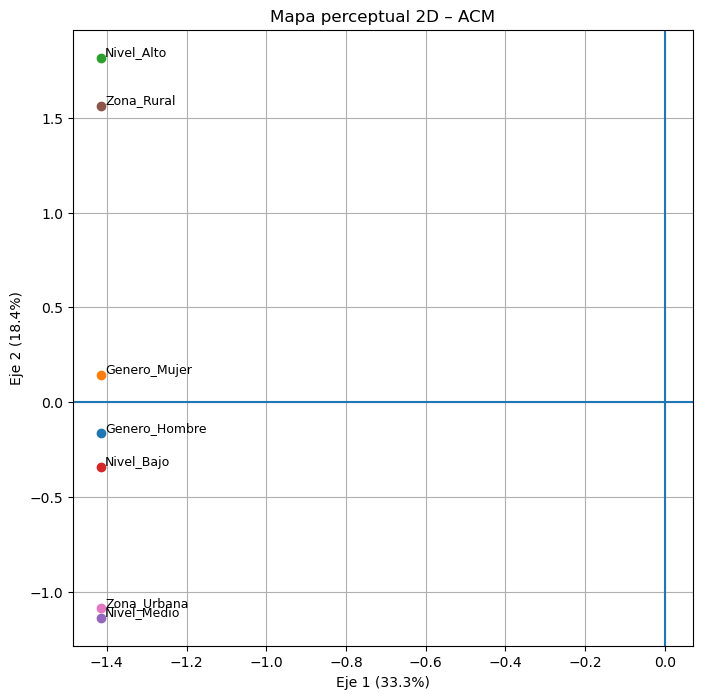

In [156]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.axhline(0)
plt.axvline(0)

for cat in coord_2d.index:
    x, y = coord_2d.loc[cat]
    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, cat, fontsize=9)

plt.xlabel(f"Eje 1 ({inercia_2d[0]:.1f}%)")
plt.ylabel(f"Eje 2 ({inercia_2d[1]:.1f}%)")
plt.title("Mapa perceptual 2D – ACM")

plt.grid(True)
plt.show()


* El eje 1 parece oponer el perfil socio–territorial más estructurado ya que está asociado a Nivel alto, Zona Rural y ligeramente género mujer y lo contrasta con zona urbana, nivel medio, nivel bajo, género hombre
* EL eje 2 por su parte muestra mayor distancia entre el grupo formado por nivel alto, zona rural contra nivel bajo y medio y zona urbana. Para este eje, el género no es relevante dado que las coordenadas están muy cerca del 0 en el eje y 

## 7 Conclusión

El mapa perceptual del ACM muestra que la estructura principal del espacio categórico está dominada por la asociación entre nivel socioeconómico y zona de residencia, mientras que el género presenta un bajo poder discriminante y se ubica cerca del perfil promedio.